# Chapter 7 - Working with Text Data

**Name:** Mohammad Fauzi Hadiwijaya  
**Course:** Machine Learning  
**Source Book:** Introduction to Machine Learning with Python

## Objectives

- Understand text data processing
- Convert text into numerical features
- Use CountVectorizer
- Build text classification model
- Visualize word frequency

## What is Text Data?

Text data cannot be used directly by machine learning models.

We must convert words into numbers using techniques such as:

- Bag of Words
- CountVectorizer
- TF-IDF

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report

## Example Dataset

We create a simple spam message dataset.

In [2]:
data = {
    "text": [
        "win money now",
        "claim your free prize",
        "hello how are you",
        "meeting today at office",
        "free gift available now",
        "let us study machine learning",
        "earn money fast now",
        "project meeting tomorrow"
    ],

    "label": [
        "spam",
        "spam",
        "ham",
        "ham",
        "spam",
        "ham",
        "spam",
        "ham"
    ]
}

df = pd.DataFrame(data)
df

,text,label
0,win money now,spam
1,claim your free prize,spam
2,hello how are you,ham
3,meeting today at office,ham
4,free gift available now,spam
5,let us study machine learning,ham
6,earn money fast now,spam
7,project meeting tomorrow,ham


## Label Distribution

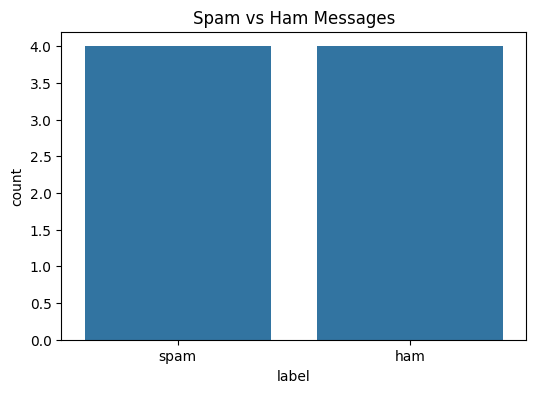

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Messages")
plt.show()

## Convert Text to Numbers

In [4]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["text"])
y = df["label"]

In [5]:
# Top words frequency
word_counts = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

word_counts.sum().sort_values(ascending=False).head(10)

,0
now,3
free,2
meeting,2
money,2
at,1
claim,1
fast,1
available,1
earn,1
are,1


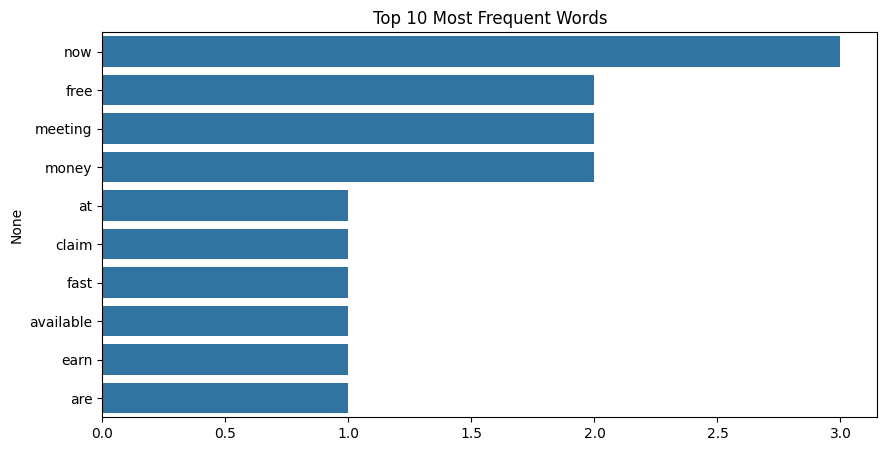

In [6]:
top_words = word_counts.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_words.values, y=top_words.index)

plt.title("Top 10 Most Frequent Words")
plt.show()

## Train Text Classification Model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [8]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



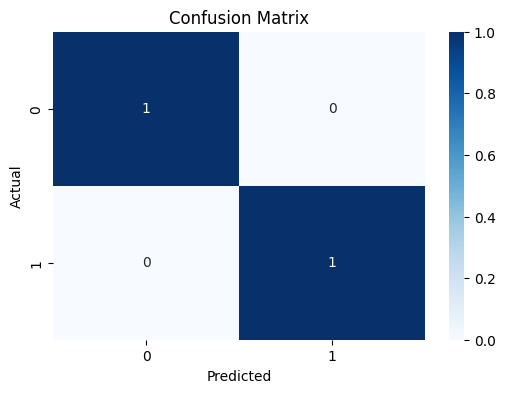

In [9]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Interpretation

The model successfully classifies spam and normal messages.

Frequent words such as "free", "money", and "now" are strong indicators of spam.

## Conclusion

- Text data must be converted into numbers.
- CountVectorizer transforms words into numeric counts.
- Naive Bayes works well for text classification.